# Mise en oeuvre de CAH sur les données Iris



In [1]:
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

from sklearn.cluster import AgglomerativeClustering
linkages = ['single','complete','average', 'ward']


iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=['sepal length','sepal width', 'petal length','petal width'])
y = pd.DataFrame(iris.target, columns=['espece'])


/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
iris_groups = {}
for linkage in linkages:
    iris_groups[linkage]=AgglomerativeClustering(3,linkage=linkage).fit_predict(X)
    
    

<AxesSubplot:xlabel='petal length', ylabel='sepal width'>

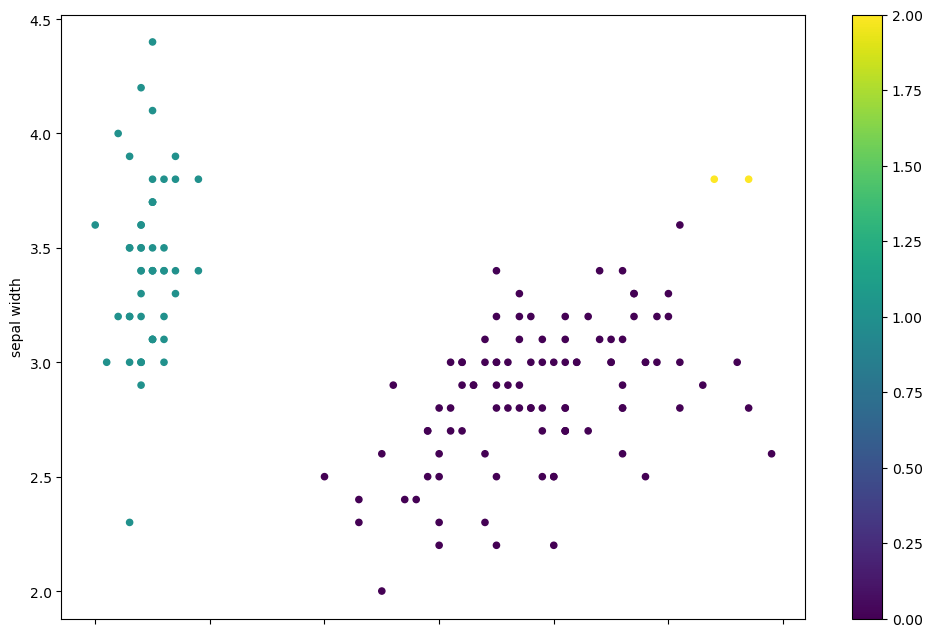

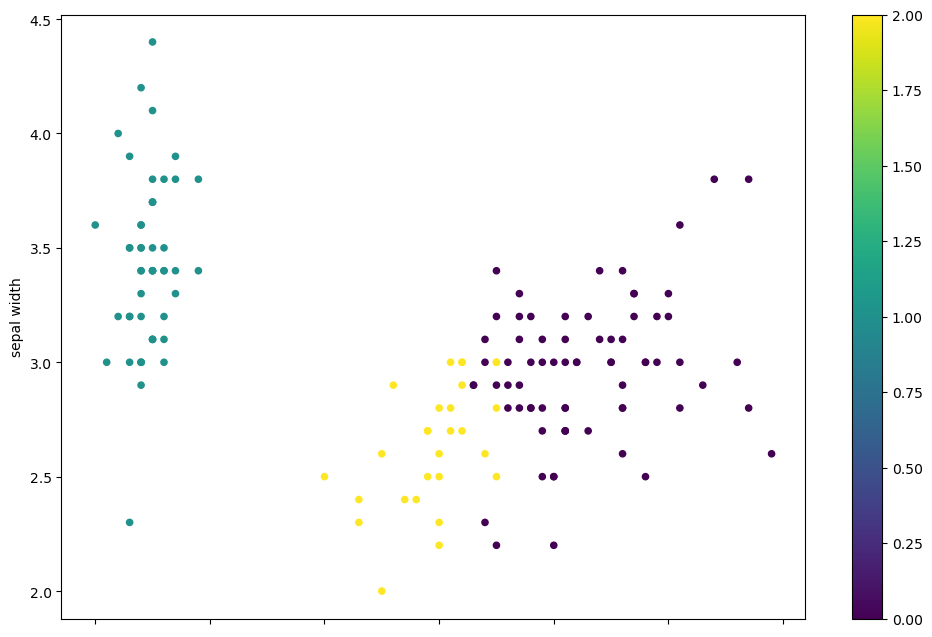

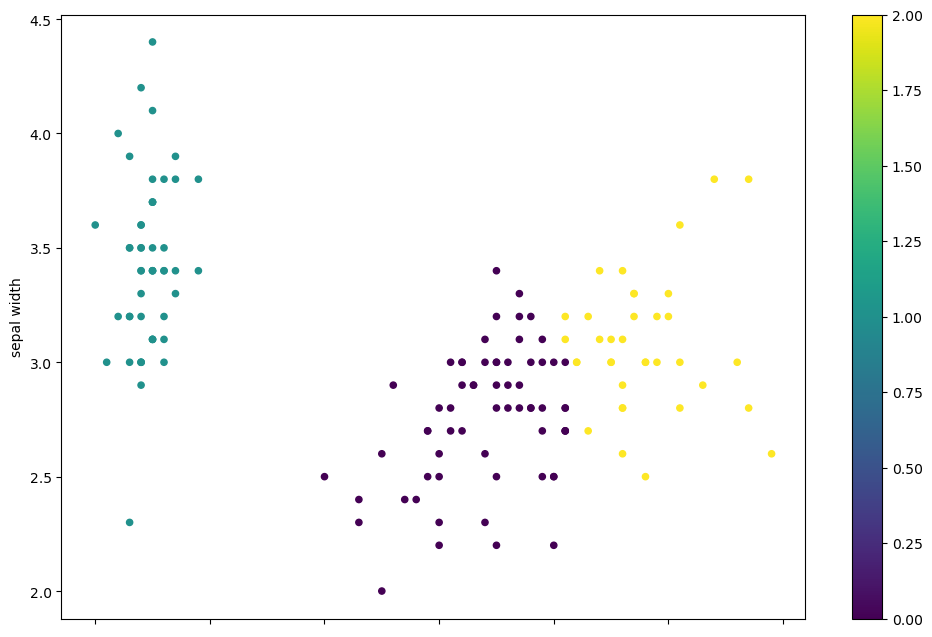

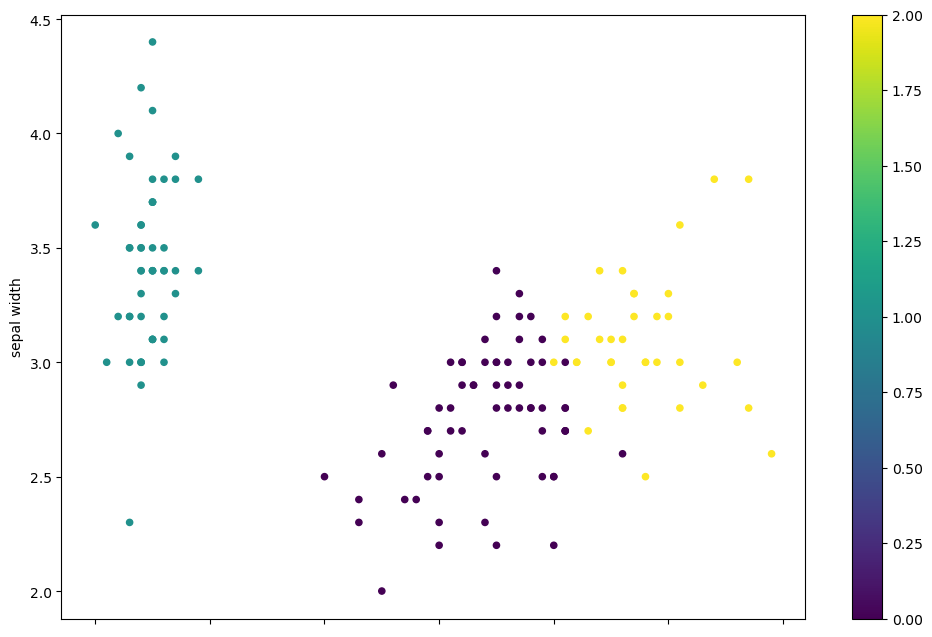

In [66]:
df = X[['petal length','sepal width']] 

df.plot.scatter(x='petal length', y='sepal width', c=iris_groups['single'], colormap='viridis')
df.plot.scatter(x='petal length', y='sepal width', c=iris_groups['complete'], colormap='viridis')
df.plot.scatter(x='petal length', y='sepal width', c=iris_groups['average'], colormap='viridis')
df.plot.scatter(x='petal length', y='sepal width', c=iris_groups['ward'], colormap='viridis')


Lorsque le nombre de groupes à découvrir n'est pas spécifié (l'on initialise l'algorithme avec les paramètres distance_threshold=0 et n_clusters=None). Il est possible d'afficher le dendrogramme (utiliser la fonction disponible https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html )

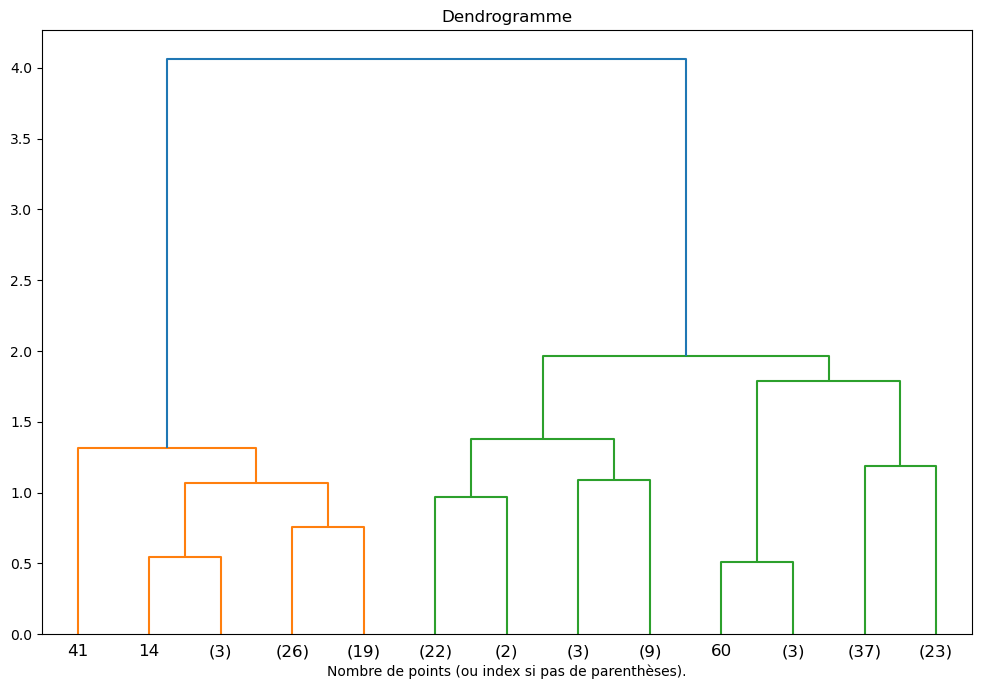

In [64]:
from scipy.cluster.hierarchy import dendrogram

#help(dendrogram)
def plot_dendrogram(model, **kwargs):
    
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='average')

model = model.fit(X)
plt.title('Dendrogramme')
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode='level', p=3, distance_sort=True)
plt.xlabel("Nombre de points (ou index si pas de parenthèses).")
plt.show()


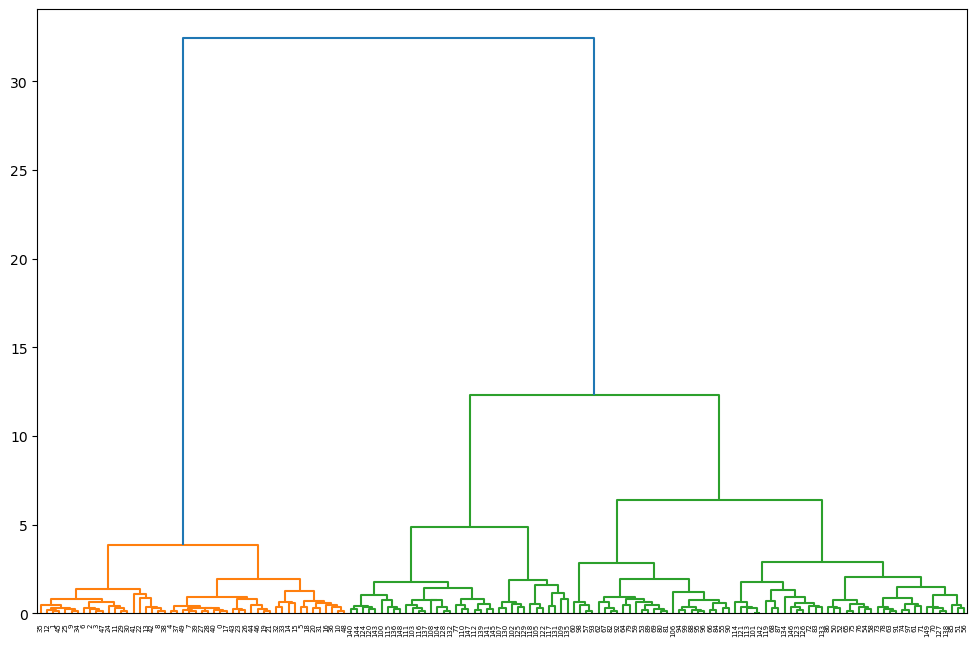

In [65]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
model.fit(X)
plot_dendrogram(model, distance_sort=True)


<AxesSubplot:xlabel='petal length', ylabel='sepal width'>

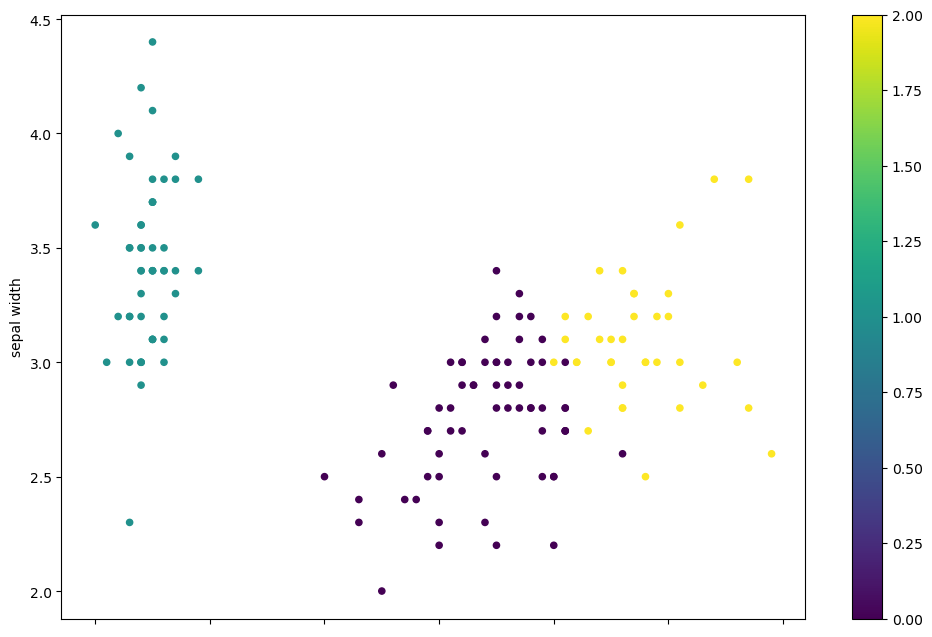

In [60]:
iris_groups =AgglomerativeClustering(3,linkage='ward').fit_predict(X)
    
    
df.plot.scatter(x='petal length', y='sepal width', c=iris_groups, colormap='viridis')
